In [1]:
import os
import sys

for _ in range(4):
    os.chdir("..")

# os.getcwd()

In [2]:
RANDOM_SEED = 42
PROJECT_PATH = './projects/main'
SOURCE_FILENAME = 'dayuses.csv'

### Imports

In [3]:
from datetime import datetime, timedelta
import pandas as pd
import numpy as np
pd.set_option('display.max_columns', None)
import scipy.stats as ss
from sklearn.model_selection import train_test_split
from catboost import CatBoostRegressor, CatBoostClassifier, monoforest
from matplotlib import pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

In [4]:
%run projects/scripts/reload

### Source file

\- Quick look at raw CSV  
Same anonymized day-level user activity log (~49.4M rows, 830K users).

In [5]:
pd.read_csv(PROJECT_PATH + '/source/' + SOURCE_FILENAME)

,event_date,search,cat,has_search_to_cart,has_search_to_ord,has_cat_to_cart,has_cat_to_ord,search_to_cart,search_to_ord,cat_to_cart,cat_to_ord,gmv_search,gmv_cat,to_cart,to_ord,gmv,searches,user_id
0,2025-01-01,1,1,1,0,1,0,1,0,1,0,0.000000,0.0,2,0,0.000000,3,704555
1,2025-01-01,1,0,0,0,0,0,0,0,0,0,0.000000,0.0,0,0,0.000000,2,588098
2,2025-01-01,1,1,0,0,0,0,0,0,0,0,0.000000,0.0,0,0,0.000000,1,257110
3,2025-01-01,1,0,1,1,0,0,2,2,0,0,53.693340,0.0,2,2,53.693340,2,249640
4,2025-01-01,1,0,1,1,0,0,3,3,0,0,723.934309,0.0,3,3,723.934309,7,151379
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49414699,2025-10-31,0,0,0,0,0,0,0,0,0,0,0.000000,0.0,0,0,0.000000,0,259179
49414700,2025-10-31,1,0,0,0,0,0,0,0,0,0,0.000000,0.0,0,0,0.000000,7,365839
49414701,2025-10-31,0,1,0,0,0,0,0,0,0,0,0.000000,0.0,0,0,0.000000,0,131933
49414702,2025-10-31,1,0,1,0,0,0,1,0,0,0,0.000000,0.0,1,0,0.000000,1,671156


# 0. Data Loading and Processing

\- Required columns for validation

In [6]:
required_columns = [
    'search', 'cat',
    'has_search_to_cart', 'has_search_to_ord',
    'has_cat_to_cart', 'has_cat_to_ord',
    'search_to_cart', 'search_to_ord',
    'cat_to_cart', 'cat_to_ord',
    'gmv_search', 'gmv_cat',
    'to_cart', 'to_ord', 'gmv', 'searches'
]

\- Initialize and load SessionProcessor

In [7]:
USER_ID_COL = 'user_id'
session_processor_kwargs = {
    'timestamp_col': 'event_date',
    'user_id_col': USER_ID_COL,
    'required_columns': required_columns # optional check
}
session_processor = SessionProcessor(**session_processor_kwargs)
session_processor.load(file_path=PROJECT_PATH + '/source/' + SOURCE_FILENAME)

,event_date,search,cat,has_search_to_cart,has_search_to_ord,has_cat_to_cart,has_cat_to_ord,search_to_cart,search_to_ord,cat_to_cart,cat_to_ord,gmv_search,gmv_cat,to_cart,to_ord,gmv,searches,user_id
0,2025-01-01,1,1,1,0,1,0,1,0,1,0,0.000000,0.0,2,0,0.000000,3,704555
70093,2025-01-01,1,0,0,0,0,0,0,0,0,0,0.000000,0.0,0,0,0.000000,1,226882
70092,2025-01-01,1,1,0,0,0,0,0,0,0,0,0.000000,0.0,0,0,0.000000,2,198016
70091,2025-01-01,1,1,1,1,0,0,1,1,0,0,57.034206,0.0,1,1,57.034206,4,453919
70090,2025-01-01,0,1,0,0,0,0,0,0,0,0,0.000000,0.0,0,0,0.000000,0,10681
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49283909,2025-10-31,1,1,1,1,0,0,2,2,0,0,75.776274,0.0,2,2,75.776274,4,530266
49283910,2025-10-31,1,0,1,0,0,0,1,0,0,0,0.000000,0.0,1,0,0.000000,1,475856
49283911,2025-10-31,0,0,0,0,0,0,0,0,0,0,0.000000,0.0,0,0,0.000000,0,517508
49283902,2025-10-31,1,0,1,1,0,0,1,1,0,0,15.485823,0.0,1,1,15.485823,4,280717


\- Total unique users in the dataset

Confirms we have ~830K unique users.

In [8]:
session_processor.get_users_power()

829468

## 0.1 Feature Engineering

\- Define aggregation rules (MapReduce pattern)

Identical to the orbital notebook: same MapReduceRules for day-level  
and 30-day period-level aggregation (frequency, recency, gmv, etc.)  
(See orbital notebook correspondig cells for detailed comments on each rule.)

In [9]:
parse_session = [
    MapReduceRule(lambda row: 1 * (row['search'] + row['cat'] > 0), 'max', alias='is_active'),
    MapReduceRule('gmv', 'sum'),
    MapReduceRule('search', 'max'),
    MapReduceRule('cat', 'max'),
    MapReduceRule(lambda row: 1 * (row['has_search_to_cart'] + row['has_cat_to_cart'] > 0), 'max', alias='has_to_cart'),
    MapReduceRule(lambda row: 1 * (row['has_search_to_ord'] + row['has_cat_to_ord'] > 0), 'max', alias='has_to_ord'),
    MapReduceRule(lambda row: row['search_to_cart'] + row['cat_to_cart'], 'sum', alias='to_cart'),
    MapReduceRule(lambda row: row['search_to_ord'] + row['cat_to_ord'], 'sum', alias='to_ord'),
]


parse_discrete_events = [
    MapReduceRule(
        'is_active',
        'sum', alias='frequency'
    ), 
    MapReduceRule(
        lambda row: row['period'] if row['is_active'] > 0 else None,
        'max', alias='recency'
    ), 
    MapReduceRule(
        'gmv', 'sum'
    ),
    MapReduceRule('search', 'sum'),
    MapReduceRule('cat', 'sum'),
    MapReduceRule('has_to_cart', 'sum'),
    MapReduceRule('has_to_ord', 'sum'),
    MapReduceRule('to_cart', 'sum'),
    MapReduceRule('to_ord', 'sum'),
]

# Feature rule: 30-day rolling window, daily granularity
cmplx_feature_rule = AggregationRule(
    freq='D',
    periods = 30,
    parse_sessions=parse_session,
    parse_discrete_events=parse_discrete_events,
)

# Target rule: 30-day forward GMV (= lLTV)
m_target_rule = AggregationRule(
    freq='D',
    periods = 30,
    parse_sessions=[MapReduceRule('gmv', 'sum')],
    parse_discrete_events=[MapReduceRule('gmv', 'sum')],
)

# 2. Learnig to Orbital Segmentation

1.  **Train** model to predict target. *(CatBoost)*
2.  **Extract** Polynomial Representation from (CatBoost) Decision Tree. *(Monoforest)*
3.  **Extract** Table Rule from Polynomial Representation of (CatBoost) Decision Tree. *(PolyForest)*
4.  **Compact** Table Rule to constrained number of rules. *(CompactOperator)*

\- Define feature and target column names

In [10]:
FEATURES = [
    'frequency_0', 'recency_0', 'gmv_0'
] + [
    'search_0', 'cat_0', 'has_to_cart_0', 'has_to_ord_0', 'to_cart_0', 'to_ord_0'
]
TARGET = 'gmv_target'

\- Artifact location tag

In [11]:
LOCATION = 'orbital'

## LOAD

In [12]:
rule_extractor_pipeline = RuleExtractorPipeline(project_path=PROJECT_PATH)
rule_extractor_pipeline.load_rule(
    rel_path_to_polyforest=f'/artifacts/learning/info/polynomial_form/{LOCATION}.yaml',
    rel_path_to_compact_op=f'/artifacts/learning/info/compact/{LOCATION}.yaml'
)

Rule(_assign_label=<bound method BaseCompactOperator.assign_label of <src.table.compact.simple_compact.SimpleCompactOperator object at 0x11c25a120>>, _labels=['out', 'F2', 'F1', 'D2', 'D1', 'B2', 'B1', 'A1', 'other'], _result_col='orbit')

# 3. Orbital Evaluation over Time (Stream)

In [13]:
STREAM_DIRNAME = 'sample-0.1'


stream_extractor = FeatureExtractor(
    session_processor = session_processor,
    feature_rules = [cmplx_feature_rule],
    target_rule = m_target_rule
)

orbital_processor = OrbitalProcessor(
    feature_extractor=stream_extractor,
    rule=rule_extractor_pipeline.rule,
    dirname=STREAM_DIRNAME,
    project_path=PROJECT_PATH,
)

## 3.2 Orbital Potential Estimation

### Save/Load checkpoint

\- Load pre-estimated V_c: average lLTV per orbital 

In [14]:
# Save
# orbital_processor.save_hats()
# Load
hat_potentials = orbital_processor.load_hats()
hat_potentials

orbit
out        4.172585
F2        17.090333
F1        35.543307
D2        48.231119
D1        68.003036
B2        81.720797
B1       132.737214
A1       384.537662
other    201.828216
Name: gmv_target, dtype: float64

# 4. Run Experiment

Wrap the orbital machinery into an experiment framework and create an AA split:  
two random groups with no real treatment. This setup stresses the estimators under the null.

In [15]:
%%time


ab_test = ABTestFramework(orbital_processor)

# Experiment window (start, end]
start, end = pd.to_datetime('2025-02-08'), pd.to_datetime('2025-03-10')

# Eligible users: alive at the first full experiment day
alive_users = session_processor.filter(
    start,  start + pd.Timedelta(1, 'D')
)[USER_ID_COL].unique()

# For AA all alive users are included
exp_users = alive_users

# Random split into control/test
np.random.seed(RANDOM_SEED)
is_control = np.random.choice(2, size=exp_users.size)
groups = {
    'control': exp_users[is_control == 1],
    'test': exp_users[is_control == 0]
}

CPU times: user 1.31 s, sys: 3.31 s, total: 4.62 s
Wall time: 6.85 s


For each group and user the framework computes features, orbitals, orbital potentials, and realized GMV  
 at the beginning and at the end of the experiment window.

In [16]:
%%time

groups_data = ab_test.calculate(
    start=start, 
    end=end,
    groups=groups,
    with_target=True,
)

CPU times: user 4min 33s, sys: 32.6 s, total: 5min 6s
Wall time: 5min 30s


## Predictive LTV model baseline

To compare orbitals with a strong model-based alternative,  
 we also load a CatBoost regressor that directly predicts future GMV from the same features.

In [17]:
PREDICT_MODEL_LOC = 'predictive.cbm'
predict_model = CatBoostRegressor()
predict_model.load_model(PROJECT_PATH + '/artifacts/learning/info/catboost_model/' + PREDICT_MODEL_LOC)
predict_model

For each user we evaluate the predictive model at time 0 and time T,  
 then define predictive uplift as the difference between the two predictions.

In [18]:
for group in groups_data.keys():
    data = groups_data[group]

    for t in ('0', 'T'):
        FEATURES_at_t = [f'{col}_at_{t}' for col in FEATURES]
        X = data[FEATURES_at_t].copy()
        X.columns = FEATURES
        # y = predict_model.predict(X.fillna(0))
        y = predict_model.predict(X)
        data[f"predict_{TARGET}_at_{t}"] = y

    data[f"predict_{TARGET}_uplift"] = data[f"predict_{TARGET}_at_T"] - data[f"predict_{TARGET}_at_0"]

## Describe

In [19]:
groups_data['control'].describe()

,frequency_0_at_0,recency_0_at_0,gmv_0_at_0,search_0_at_0,cat_0_at_0,has_to_cart_0_at_0,has_to_ord_0_at_0,to_cart_0_at_0,to_ord_0_at_0,gmv_target_at_0,hat_gmv_target_at_0,frequency_0_at_T,recency_0_at_T,gmv_0_at_T,search_0_at_T,cat_0_at_T,has_to_cart_0_at_T,has_to_ord_0_at_T,to_cart_0_at_T,to_ord_0_at_T,gmv_target_at_T,hat_gmv_target_at_T,hat_gmv_target_uplift,predict_gmv_target_at_0,predict_gmv_target_at_T,predict_gmv_target_uplift
count,74102.000000,73562.000000,74102.000000,74102.000000,74102.000000,74102.000000,74102.000000,74102.000000,74102.000000,76013.000000,76013.000000,76013.000000,75527.000000,76013.000000,76013.000000,76013.000000,76013.000000,76013.000000,76013.000000,76013.000000,72976.000000,76013.000000,76013.000000,76013.000000,76013.000000,76013.000000
mean,11.796807,27.435524,116.150225,11.183261,2.764055,5.077596,1.932134,14.596799,3.335983,130.087249,105.954421,12.395248,26.171144,130.087249,11.737558,2.944325,5.437754,2.188626,15.702459,3.791930,122.215395,118.234701,12.280280,101.954460,113.797847,11.843387
std,7.219320,4.559372,347.359820,7.093156,3.921878,4.894391,2.592012,27.349620,7.087294,363.484313,107.206483,7.229177,6.552637,363.484313,7.117053,4.053366,5.059797,2.777932,27.690210,7.430207,325.186180,112.690400,98.731271,145.027369,156.246575,130.386778
min,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.172585,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.172585,-367.447329,4.602868,4.918343,-3236.350868
25%,6.000000,27.000000,0.000000,5.000000,0.000000,1.000000,0.000000,2.000000,0.000000,0.000000,35.543307,6.000000,26.000000,0.000000,6.000000,0.000000,1.000000,0.000000,2.000000,0.000000,0.000000,35.543307,-18.452974,32.087768,35.706574,-19.326772
50%,11.000000,29.000000,22.689975,10.000000,1.000000,4.000000,1.000000,6.000000,1.000000,29.311375,68.003036,12.000000,29.000000,29.311375,11.000000,1.000000,4.000000,1.000000,7.000000,2.000000,24.043752,68.003036,0.000000,59.899510,68.272042,4.200334
75%,17.000000,30.000000,108.323736,16.000000,4.000000,7.000000,3.000000,17.000000,4.000000,127.210449,201.828216,18.000000,30.000000,127.210449,17.000000,4.000000,8.000000,3.000000,19.000000,5.000000,116.123607,201.828216,46.177489,119.589883,135.158916,38.312443
max,30.000000,30.000000,32651.133446,30.000000,30.000000,30.000000,30.000000,2993.000000,238.000000,26763.075671,384.537662,30.000000,30.000000,26763.075671,30.000000,30.000000,30.000000,29.000000,1832.000000,204.000000,14623.053067,384.537662,380.365077,4164.562422,6142.025436,4849.687411


In [20]:
groups_data['test'].describe()

,frequency_0_at_0,recency_0_at_0,gmv_0_at_0,search_0_at_0,cat_0_at_0,has_to_cart_0_at_0,has_to_ord_0_at_0,to_cart_0_at_0,to_ord_0_at_0,gmv_target_at_0,hat_gmv_target_at_0,frequency_0_at_T,recency_0_at_T,gmv_0_at_T,search_0_at_T,cat_0_at_T,has_to_cart_0_at_T,has_to_ord_0_at_T,to_cart_0_at_T,to_ord_0_at_T,gmv_target_at_T,hat_gmv_target_at_T,hat_gmv_target_uplift,predict_gmv_target_at_0,predict_gmv_target_at_T,predict_gmv_target_uplift
count,73997.000000,73437.000000,73997.000000,73997.000000,73997.000000,73997.000000,73997.000000,73997.000000,73997.000000,75947.000000,75947.000000,75947.000000,75496.000000,75947.000000,75947.000000,75947.000000,75947.000000,75947.000000,75947.000000,75947.000000,73033.000000,75947.000000,75947.000000,75947.000000,75947.000000,75947.000000
mean,11.827709,27.457154,118.460112,11.220495,2.779356,5.094098,1.946755,14.669973,3.395165,133.752185,106.201835,12.438319,26.216753,133.752185,11.777648,2.973653,5.443098,2.202312,15.798794,3.873728,127.402742,118.449667,12.247832,102.953507,115.267315,12.313808
std,7.241726,4.531039,469.148175,7.117970,3.959114,4.941377,2.627361,25.337716,7.407027,508.551070,108.022076,7.246521,6.453495,508.551070,7.124070,4.114619,5.088696,2.811928,26.764795,7.896985,446.293193,113.003028,98.090781,153.511112,196.543666,162.170825
min,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.172585,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.172585,-367.447329,4.602868,4.918343,-7206.207092
25%,6.000000,27.000000,0.000000,5.000000,0.000000,1.000000,0.000000,2.000000,0.000000,0.000000,35.543307,6.000000,26.000000,0.000000,6.000000,0.000000,1.000000,0.000000,2.000000,0.000000,0.000000,35.543307,-18.452974,32.062602,35.513573,-18.954043
50%,11.000000,29.000000,22.348821,10.000000,1.000000,4.000000,1.000000,6.000000,1.000000,29.328194,68.003036,12.000000,29.000000,29.328194,11.000000,1.000000,4.000000,1.000000,7.000000,2.000000,24.764706,68.003036,0.000000,59.803546,68.141340,4.346263
75%,17.000000,30.000000,109.231095,16.000000,4.000000,7.000000,3.000000,17.000000,4.000000,129.146820,201.828216,18.000000,30.000000,129.146820,17.000000,4.000000,8.000000,3.000000,19.000000,5.000000,117.329739,201.828216,46.177489,119.609095,136.583710,38.508328
max,30.000000,30.000000,64491.843849,30.000000,30.000000,30.000000,30.000000,880.000000,290.000000,73148.827363,384.537662,30.000000,30.000000,73148.827363,30.000000,30.000000,30.000000,29.000000,1328.000000,232.000000,47037.145785,384.537662,380.365077,7466.441174,31369.894391,26082.785534


## Report

\- Metrics to compare

Define the set of metrics to compare between control and test:  
 orbital-based uplift and levels, realized GMV, and predictive uplift and levels.

In [46]:
COLORS = ['blue', 'purple', 'red', 'orange', 'green']
ALIASES = ['$r_{V\\text{-corrected}}$', '$r_V$', 'Direct lLTV', '$r_{\\text{pred-corrected}}$', '$r_{\\text{pred}}$']
METRICS_TO_REPORT = [
    (f'hat_{TARGET}_uplift',      f'hat_{TARGET}_at_T'),
    (f'hat_{TARGET}_at_T',        None),
    (f'{TARGET}_at_T',            None),
    (f'predict_{TARGET}_uplift',  f'predict_{TARGET}_at_T'),
    (f'predict_{TARGET}_at_T',    None),
]
METRICS_TO_REPORT

[('hat_gmv_target_uplift', 'hat_gmv_target_at_T'),
 ('hat_gmv_target_at_T', None),
 ('gmv_target_at_T', None),
 ('predict_gmv_target_uplift', 'predict_gmv_target_at_T'),
 ('predict_gmv_target_at_T', None)]


1. `hat_gmv_target_uplift` – orbital-based uplift in lLTV,
2. `hat_gmv_target_at_T` – orbital-based lLTV level at the end of the window,
3. `gmv_target_at_T` – realized lLTV,
4. `predict_gmv_target_uplift` – predictive uplift in lLTV,
5. `predict_gmv_target_at_T` – predicted lLTV at T.

In [47]:
for metric, _ in METRICS_TO_REPORT:
    µ_B = groups_data['test'].describe().loc['mean', metric]
    µ_A = groups_data['control'].describe().loc['mean', metric]
    delta = µ_B - µ_A
    print(f"∆ {metric}:", delta)


∆ hat_gmv_target_uplift: -0.032447922753538805
∆ hat_gmv_target_at_T: 0.21496613190113578
∆ gmv_target_at_T: 5.182005373356816
∆ predict_gmv_target_uplift: 0.47042087398264343
∆ predict_gmv_target_at_T: 1.4694677320840128


### $\Delta$

In [48]:
%%time

report = ab_test.get_report(
    variants=groups.keys(),
    control='control',
    metrics=METRICS_TO_REPORT,
)

report

CPU times: user 1min 29s, sys: 1min 5s, total: 2min 35s
Wall time: 6min 24s


,control,test,metric,∆,p-value,σ,ci,sample,kind
0,control,test,hat_gmv_target_uplift,-0.032448,0.952667,0.516839,"[-1.0274729280216046, 0.9693588798552454]","[[-0.15658364626960974, 0.6564343193627735, -0...",
1,control,test,hat_gmv_target_at_T,0.214966,0.702667,0.557841,"[-0.8717280496423274, 1.3162013807577349]","[[0.5301344846868261, 0.28652486834876356, -0....",
2,control,test,gmv_target_at_T,5.182005,0.005333,1.874746,"[1.5312325431154303, 8.94624659322027]","[[7.362075257817892, 6.4702049604284895, 3.733...",
3,control,test,predict_gmv_target_uplift,0.470421,0.540667,0.778316,"[-1.01628689708912, 2.009215164110973]","[[0.110769314931769, -0.3576515484322176, -0.5...",
4,control,test,predict_gmv_target_at_T,1.469468,0.098000,0.884633,"[-0.24680720446567006, 3.2644293161304363]","[[1.8052339407041131, 0.41353699908137287, -0....",


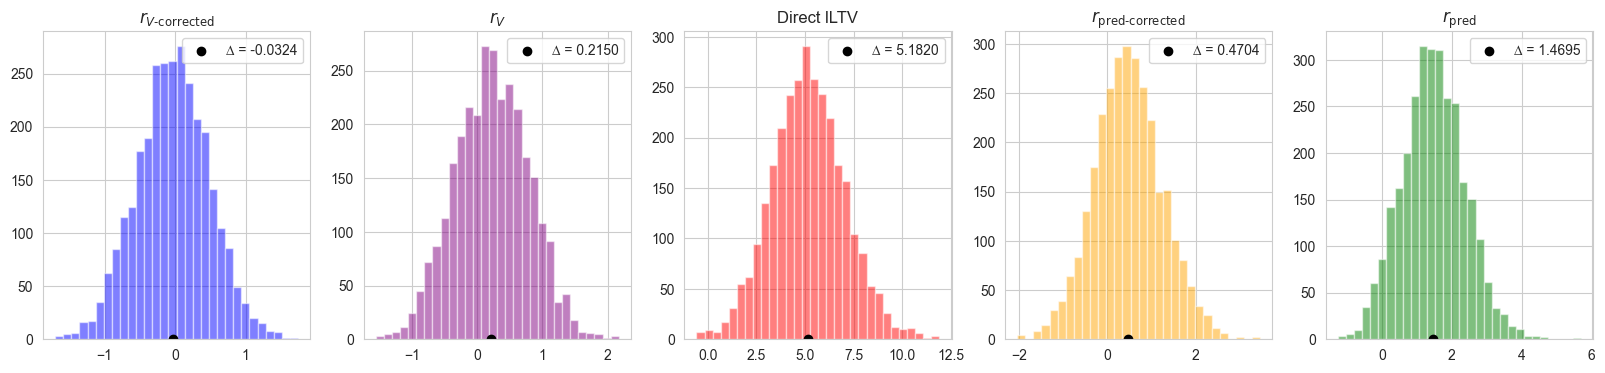

In [49]:
fig, axs = plt.subplots(1, report.shape[0], figsize=(report.shape[0] * 4, 4))


for idx, row in report.iterrows():
    sample = row['sample'].squeeze()
    axs[idx].hist(sample, bins=30, color=COLORS[idx], alpha = 0.5)
    axs[idx].scatter(row['∆'], 0, color='black', label=f"∆{row['kind']} = {row['∆']:.4f}")
    # axs[idx].set_title(row['metric'])
    axs[idx].set_title(ALIASES[idx])
    axs[idx].legend()

plt.show()

### $\Delta$, %

In [50]:
%%time

report = ab_test.get_report(
    variants=groups.keys(),
    control='control',
    metrics=METRICS_TO_REPORT,
    proportional=True,
)

report

CPU times: user 1min 27s, sys: 53.4 s, total: 2min 20s
Wall time: 4min 7s


,control,test,metric,∆,p-value,σ,ci,sample,kind
0,control,test,hat_gmv_target_uplift,-0.027444,0.952667,0.435795,"[-0.8683097765408951, 0.8232782636003004]","[[-0.1321990706129735, 0.5546165813402794, -0....",%
1,control,test,hat_gmv_target_at_T,0.181813,0.702667,0.472130,"[-0.7313654666159665, 1.1157121834358565]","[[0.4475773035379113, 0.24208277700475261, -0....",%
2,control,test,gmv_target_at_T,4.416516,0.005333,1.630449,"[1.2903366338399747, 7.713895828267924]","[[6.23691066107765, 5.550047707897734, 3.17929...",%
3,control,test,predict_gmv_target_uplift,0.413383,0.540667,0.684505,"[-0.8869321381148589, 1.7704580157304888]","[[0.09696600460178241, -0.31313213781209304, -...",%
4,control,test,predict_gmv_target_at_T,1.291297,0.098000,0.780035,"[-0.21571002791181013, 2.88393689121405]","[[1.5802781005681292, 0.3620611322791161, -0.4...",%


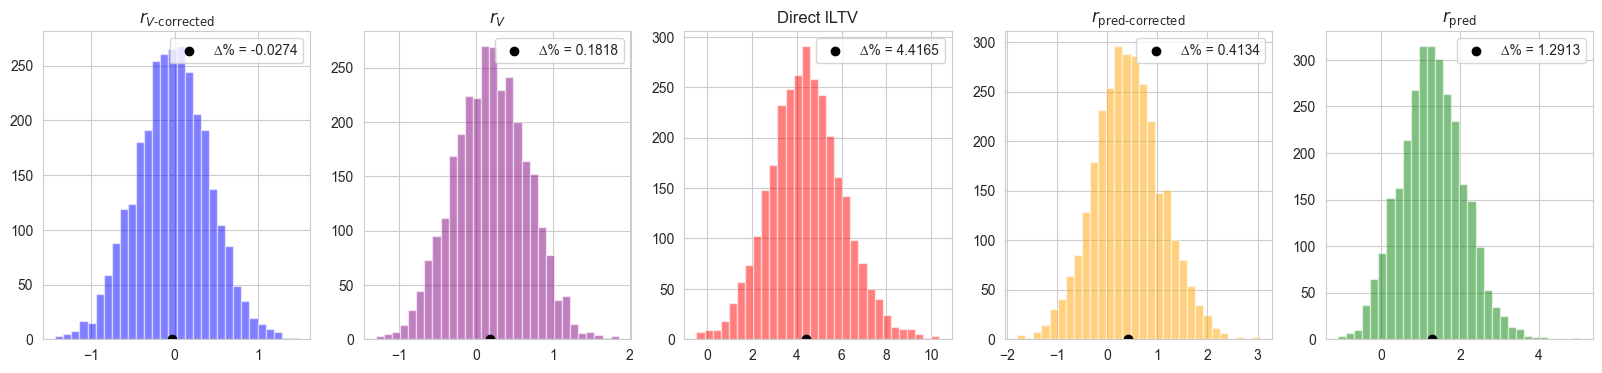

In [51]:
fig, axs = plt.subplots(1, report.shape[0], figsize=(report.shape[0] * 4, 4))


for idx, row in report.iterrows():
    sample = row['sample'].squeeze()
    axs[idx].hist(sample, bins=30, color=COLORS[idx], alpha = 0.5)
    axs[idx].scatter(row['∆'], 0, color='black', label=f"∆{row['kind']} = {row['∆']:.4f}")
    # axs[idx].set_title(row['metric'])
    axs[idx].set_title(ALIASES[idx])
    axs[idx].legend()

plt.show()